# 第42课 · 🎨 看见 FFT 的心跳——蝴蝶图（butterfly）与纯音 / 和弦 / 噪声的频谱指纹

**目标**：用图建立 FFT 的视觉记忆——蝶形、纯音/和弦/噪声的频谱指纹。

> **🎨 读法**：轻文字，**读图挑战优先**；巩固 L37–L41，不新开长推导。

🔗 Aurora 连接：`aurora.audio.transforms.fft` · `aurora.audio.io.sine`

← **上一课**　[L41 · 加窗 FFT 完整流程](L41_fft_full.ipynb)

> 上节课学习了 **加窗 FFT 完整流程**：信号 → 加窗 → FFT → 幅度谱，一条管线跑通。  
> 本课将探讨 **FFT 图形化**。

## 核心直觉

DFT 本质是一次矩阵-向量乘法：把时域（time domain）信号投影到 N 个不同频率的复指数（complex exponential）基上。FFT 的魔法在于这个 N×N 矩阵有高度冗余——把它递归地折叠成两半，计算量从 `O(N²)` 降到 `O(N log N)`，每一层折叠对应图中的一组蝶形操作。

## 准备工作：复指数与欧拉公式

在谈 FFT 之前，需要理解"复指数"这个概念。你会在很多地方看到 `exp(-2πi·k·n/N)`，这究竟是什么东西？

**欧拉公式** 是联系复数和三角函数的最重要的桥梁。它说：

$$e^{ix} = \cos(x) + i \sin(x)$$

这意味着：
- 当 $x = \pi$ 时，$e^{i\pi} = \cos(\pi) + i\sin(\pi) = -1$（最优雅的等式）
- 当 $x = 2\pi$ 时，$e^{i·2\pi} = 1$（回到起点）
- 当 $x = \pi/2$ 时，$e^{i\pi/2} = i$（纯虚数）

**复指数 $e^{i\theta}$ 在复平面上的图像**：是一个**旋转运动**。以原点为中心，模长（距离原点的距离）始终为 1，相位（角度）为 $\theta$。

*为什么这对 DFT 有用？*
- 频率分析就是拿不同频率的复指数去"旋转地扫过"信号
- 如果信号里恰好有这个频率，复指数会与信号对齐，累加和很大（尖峰）
- 如果没有这个频率，复指数旋转不对齐，累加和很小

**数值例子**：
- $e^{i·0} = 1$（不旋转）
- $e^{i·\pi/4} = \frac{1}{\sqrt{2}} + i\frac{1}{\sqrt{2}} \approx 0.707 + 0.707i$（旋转 45°）
- $e^{i·\pi/2} = 0 + i = i$（旋转 90°）
- $e^{i·\pi} = -1 + 0i$（旋转 180°）

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import sine
from aurora.audio.transforms import fft

## 关键概念：基（basis）、投影（projection）与共轭

**"基"是什么？** 想象你在三维空间中有三个互相垂直的标准轴：x、y、z。任何三维向量都可以表示为这三个基向量的线性组合。同样，在频域中，DFT 用 N 个不同频率的复指数作为"基向量"，任何长度为 N 的信号都可以表示为这 N 个基向量的加权和。

**"投影"是什么？** 当你把一个向量投影到某个方向上，你在问："这个向量在那个方向上有多少分量？"。在 DFT 中，投影对应的就是 $X[k]$——信号在频率 k 这个方向上的"强度"。如果 $|X[k]|$ 很大，说明信号中这个频率分量很强。

**复数的共轭**：对于复数 $z = a + bi$，它的共轭记为 $\overline{z}$ 或 `conj(z)`，定义为 $\overline{z} = a - bi`。也就是说，实部不变，虚部取反。例如：
- $\overline{3 + 4i} = 3 - 4i$
- $\overline{e^{i\theta}} = e^{-i\theta}$

共轭的几何意义：在复平面上，共轭对应**关于实轴的镜像**。

---

## 1. DFT 矩阵：N×N 酉矩阵（unitary matrix）

**什么是 DFT？** 离散傅里叶变换把 N 个时域采样点转换为 N 个频域复数系数。数学形式：

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i \cdot k \cdot n / N}, \quad k = 0, 1, \ldots, N-1$$

这可以写成矩阵乘法。令 $W = e^{-2\pi i/N}$（这是一个 N 次单位根），DFT 矩阵是：

$$F[k, n] = W^{k \cdot n}, \quad k, n = 0, 1, \ldots, N-1$$

然后 $\mathbf{X} = F \cdot \mathbf{x}$。

**每一行的几何意义**：第 k 行是 $[W^{k \cdot 0}, W^{k \cdot 1}, W^{k \cdot 2}, \ldots, W^{k \cdot (N-1)}]$。当你按这一行与信号相乘再求和，你在做的是把信号与"频率 k 的复指数"做内积（投影）。实部是与余弦波的相似度，虚部是与正弦波的相似度。

**酉矩阵是什么？** 在实数情况下，"正交矩阵"满足 $A^T A = I$（转置乘以自身等于单位矩阵）。在复数情况下，我们改用共轭转置（即求转置后再对所有元素取共轭），得到"酉矩阵"的定义：

$$F \cdot F^{\dagger} = N \cdot I$$

其中 $F^{\dagger} = \overline{F^T}$ 是 F 的共轭转置，$I$ 是单位矩阵。为什么有个 N？因为标准 DFT 的定义中有归一化因子。这个性质很关键——它说明 **DFT 变换保持能量不变**（只差个常数倍数），这就是下面要讲的 Parseval 定理的数学根源。

热力图的行是频率 bin，列是时间采样点；颜色编码实部（余弦）。

酉性误差 max|F·F†  - N·I| = 3.02e-14  ✅


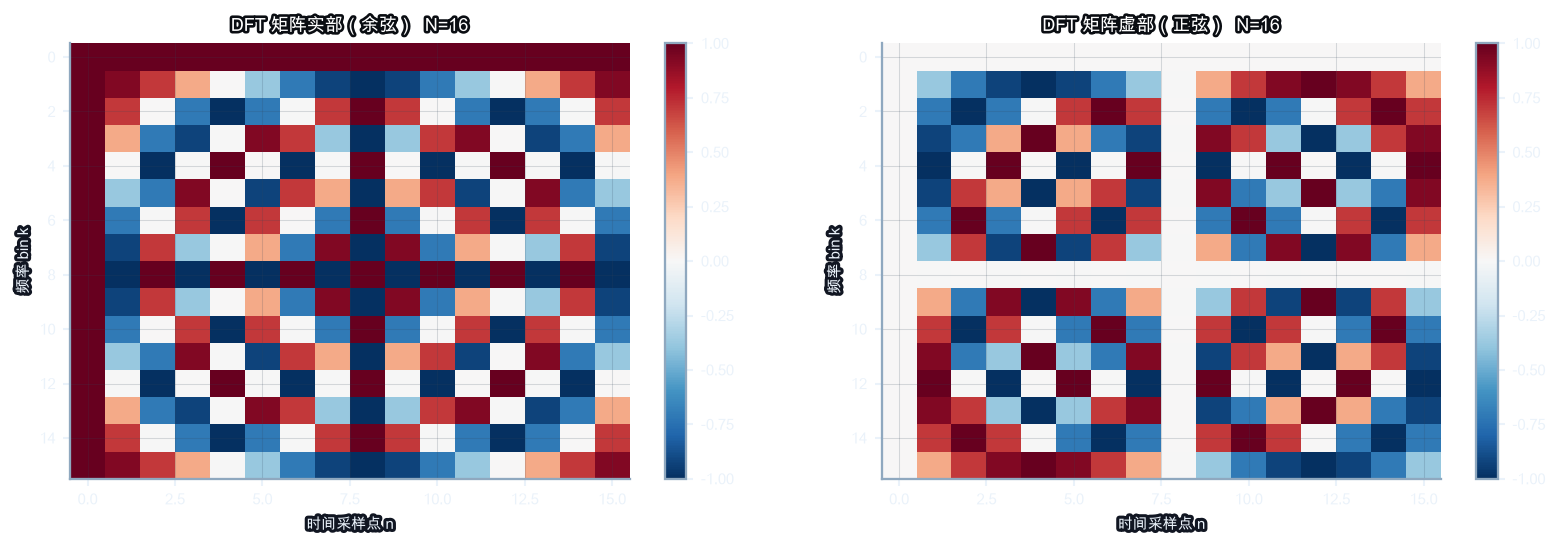

In [3]:
N = 16
n = np.arange(N)
k = np.arange(N)
# DFT 矩阵，形状 (N, N)
W = np.exp(-2j * np.pi * np.outer(k, n) / N)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(W.real, cmap='RdBu_r', aspect='auto',
                     vmin=-1, vmax=1)
axes[0].set_title(f'DFT 矩阵实部（余弦）  N={N}')
axes[0].set_xlabel('时间采样点 n')
axes[0].set_ylabel('频率 bin k')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(W.imag, cmap='RdBu_r', aspect='auto',
                     vmin=-1, vmax=1)
axes[1].set_title(f'DFT 矩阵虚部（正弦）  N={N}')
axes[1].set_xlabel('时间采样点 n')
axes[1].set_ylabel('频率 bin k')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# 验证酉性：F @ conj(F).T = N * I
err = np.max(np.abs(W @ W.conj().T - N * np.eye(N)))
print(f'酉性误差 max|F·F†  - N·I| = {err:.2e}  ✅' if err < 1e-10
      else f'酉性误差 {err:.2e}  ❌')

In [4]:
"""
为什么 DFT 矩阵的每一行实部是余弦、虚部是正弦？手工验证欧拉公式。
"""
N = 8
k_demo = 3  # 看第 3 个频率的基向量

# 根据欧拉公式，复指数分解为实部（余弦）+ 虚部（正弦）
n_vals = np.arange(N)
angles = -2 * np.pi * k_demo * n_vals / N  # 角度参数

# 直接用欧拉公式计算
complex_exp = np.exp(1j * angles)
real_part = np.cos(angles)
imag_part = np.sin(angles)

# 验证分解是否正确
print(f"第 {k_demo} 行的 DFT 矩阵元素:")
print(f"{'n':<4} {'复指数 (实+虚i)':<35} {'实部 (cos)':<15} {'虚部 (sin)':<15}")
print("-" * 70)
for n in n_vals:
    ce = complex_exp[n]
    print(f"{n:<4} {ce:<35} {real_part[n]:<15.4f} {imag_part[n]:<15.4f}")
    
# 数值验证：复指数的实部应等于余弦，虚部应等于正弦
err_real = np.max(np.abs(complex_exp.real - real_part))
err_imag = np.max(np.abs(complex_exp.imag - imag_part))
print(f"\n✅ 验证：max|Re(exp) - cos| = {err_real:.2e}, max|Im(exp) - sin| = {err_imag:.2e}")
print("\n这就是为什么 DFT 矩阵热力图的实部显示的是余弦，虚部显示的是正弦。")

第 3 行的 DFT 矩阵元素:
n    复指数 (实+虚i)                          实部 (cos)        虚部 (sin)       
----------------------------------------------------------------------
0    (1+0j)                              1.0000          -0.0000        
1    (-0.7071067811865475-0.7071067811865476j) -0.7071         -0.7071        
2    (-1.8369701987210297e-16+1j)        -0.0000         1.0000         
3    (0.7071067811865477-0.7071067811865474j) 0.7071          -0.7071        
4    (-1-3.6739403974420594e-16j)        -1.0000         -0.0000        
5    (0.7071067811865466+0.7071067811865485j) 0.7071          0.7071         
6    (5.51091059616309e-16-1j)           0.0000          -1.0000        
7    (-0.7071067811865474+0.7071067811865477j) -0.7071         0.7071         

✅ 验证：max|Re(exp) - cos| = 0.00e+00, max|Im(exp) - sin| = 0.00e+00

这就是为什么 DFT 矩阵热力图的实部显示的是余弦，虚部显示的是正弦。


## 2. 蝶形网络：分而治之

根据上一节的推导，Cooley-Tukey FFT 把长度 N 的 DFT 递推拆成两个 N/2 的 DFT：

$$X[k]     = E[k] + W^k \cdot O[k]$$
$$X[k+N/2] = E[k] - W^k \cdot O[k]$$

其中 $E[k]$ 是偶数索引输入的 N/2 点 DFT，$O[k]$ 是奇数索引的，$W^k = e^{-2\pi i k/N}$ 称为**旋转因子（twiddle factor）**。

**旋转因子的几何意义**：$W^k$ 在复平面上是一个旋转。当 $k=0$ 时，$W^0 = 1$（不旋转）；当 $k=1$ 时，$W^1 = e^{-2\pi i/N}$（旋转 $-2\pi/N$ 弧度，即负向旋转）。每个 $W^k$ 的模长 $|W^k| = 1$，所以它只改变信号的**相位**，不改变幅度。在蝶形图中，旋转因子决定了蝴蝶的上下两条路径经历的相位变化。

N=8 时共有 $\log_2(8) = 3$ 层，每层 4 个蝶形单元，总操作数 $8 \times \log_2(8) = 24$（vs 朴素 DFT $8^2=64$）。
下图用节点-连线方式画出数据流，颜色标识旋转因子的相位。

## 2.5 Cooley-Tukey 递推公式的推导

现在来看"分而治之"的数学原理。为什么把 N 点 DFT 分成两个 N/2 点 DFT 就能工作？

**从定义出发**：$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i k n / N}$

现在假设 N 是偶数，我们把求和按奇偶索引分开：

$$X[k] = \sum_{n \text{ 偶}} x[n] \cdot e^{-2\pi i k n / N} + \sum_{n \text{ 奇}} x[n] \cdot e^{-2\pi i k n / N}$$

令 $n = 2m$（偶数）或 $n = 2m+1$（奇数），$m = 0, 1, \ldots, N/2-1$：

$$X[k] = \sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i k (2m) / N} + \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i k (2m+1) / N}$$

第二项拆开指数：

$$= \sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i k m / (N/2)} + e^{-2\pi i k / N} \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i k m / (N/2)}$$

令 $E[k] = \sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i k m / (N/2)}$（偶数索引的 N/2 点 DFT）

令 $O[k] = \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i k m / (N/2)}$（奇数索引的 N/2 点 DFT）

令 $W^k = e^{-2\pi i k / N}$（旋转因子），则：

$$X[k] = E[k] + W^k \cdot O[k]$$

这对 $k = 0, 1, \ldots, N/2-1$ 成立。

**对于 $k = N/2, N/2+1, \ldots, N-1$ 呢？** 用周期性。注意 $E[k]$ 和 $O[k]$ 都是 N/2 点 DFT，所以周期为 N/2：

$$E[k + N/2] = E[k], \quad O[k + N/2] = O[k]$$

而 $W^{k+N/2} = e^{-2\pi i (k+N/2) / N} = e^{-2\pi i k / N} \cdot e^{-i\pi} = -W^k$

因此对 $k = 0, 1, \ldots, N/2-1$：

$$X[k + N/2] = E[k] - W^k \cdot O[k]$$

**小例子验证（N=4）**：输入 $x = [1, 2, 3, 4]$

```
偶数部分：x[0]=1, x[2]=3  → E = FFT([1,3])（2点）
奇数部分：x[1]=2, x[3]=4  → O = FFT([2,4])（2点）
W^0 = 1, W^1 = e^(-iπ/2) = -i
```

这个递推关系就是"蝶形"的来源。


N=8，共 3 层，每层 4 个蝶形，总操作数 = 12（vs 朴素 DFT 64）
蝶形操作：X[top] = E + W^k·O（--线），X[bot] = E − W^k·O（:线）


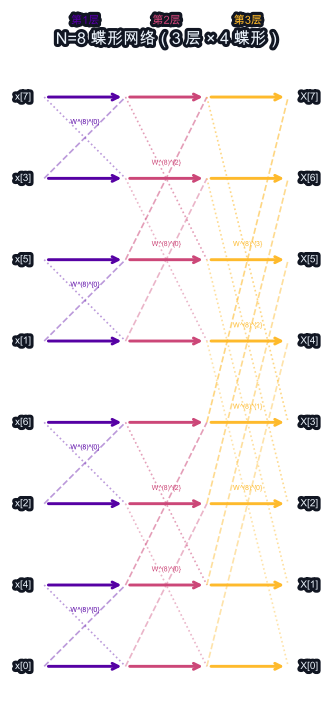

In [5]:
# 画 N=8 蝶形网络示意图（3 层，每层 4 个蝶形）
N = 8
stages = int(np.log2(N))  # 3

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(-0.3, stages + 0.3)
ax.set_ylim(-0.5, N - 0.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('N=8 蝶形网络（3 层 × 4 蝶形）', fontsize=13)

# bit-reversal 置换顺序（输入顺序）
bit_rev = [int(f'{i:03b}'[::-1], 2) for i in range(N)]

# 节点 y 坐标（输入侧按 bit-reversal 排列）
y_pos = {i: bit_rev[i] for i in range(N)}
# 从第0层到第3层均匀铺开
colors = plt.cm.plasma(np.linspace(0.15, 0.85, stages))

def node_xy(stage, wire):
    return stage, wire

# 画输入标签（bit-reversal 后的顺序）
for i in range(N):
    ax.text(-0.15, bit_rev[i], f'x[{i}]', va='center', ha='right', fontsize=8)

# 逐层画蝶形
# current_y = list(range(N))  # 预留：追踪 wire 的 y 坐标（当前未使用）
for s in range(stages):
    half = 2 ** s          # 蝶形跨度
    group = 2 * half       # 组大小
    n_butterflies = N // group  # 每层蝶形组数
    col_in  = s
    col_out = s + 1
    for g in range(n_butterflies):
        for b in range(half):
            top = g * group + b
            bot = top + half
            yt, yb = top, bot
            # 旋转因子相位（0..0.5 映射到透明度，表达相位变化）
            phase = b / group  # 0..0.5
            alpha_cross = 0.4 + 0.5 * phase  # 相位越大斜线越明显
            c = colors[s]
            # 直通线（上）
            ax.annotate('', xy=(col_out, yt), xytext=(col_in, yt),
                        arrowprops=dict(arrowstyle='->', color=c, lw=1.4))
            # 直通线（下）
            ax.annotate('', xy=(col_out, yb), xytext=(col_in, yb),
                        arrowprops=dict(arrowstyle='->', color=c, lw=1.4))
            # 交叉线 top→bot（对应 +W^k 分支）
            ax.plot([col_in, col_out], [yt, yb], color=c, lw=0.8, ls='--', alpha=alpha_cross)
            # 交叉线 bot→top（对应 -W^k 分支，完整蝴蝶形结构）
            ax.plot([col_in, col_out], [yb, yt], color=c, lw=0.8, ls=':', alpha=alpha_cross)
            # 旋转因子标注（每个蝶形均标注，指数 = b * N // group）
            mid_x = (col_in + col_out) / 2
            mid_y = (yt + yb) / 2
            exp_k = b * N // group  # 正确的旋转因子指数
            ax.text(mid_x, mid_y + 0.15,
                    f'W^({N})^{{{exp_k}}}', fontsize=5.5, color=c,
                    ha='center', va='bottom')

# 输出标签
for i in range(N):
    ax.text(stages + 0.15, i, f'X[{i}]', va='center', ha='left', fontsize=8)

# 层标签
for s in range(stages):
    ax.text(s + 0.5, N - 0.1, f'第{s+1}层', ha='center', fontsize=9,
            color=colors[s], fontweight='bold')

plt.tight_layout()
plt.show()
print(f'N={N}，共 {stages} 层，每层 {N//2} 个蝶形，总操作数 = {N//2 * stages}（vs 朴素 DFT {N*N}）')
print('蝶形操作：X[top] = E + W^k·O（--线），X[bot] = E − W^k·O（:线）')


In [6]:
"""
演示位逆序置换
"""
N = 8
log_N = 3  # log2(8)

# 计算位逆序映射
bit_rev = []
for i in range(N):
    # 把 i 转为二进制字符串（3位，不足补0），反转，再转回十进制
    binary_str = f'{i:0{log_N}b}'
    reversed_str = binary_str[::-1]
    reversed_idx = int(reversed_str, 2)
    bit_rev.append(reversed_idx)

print("位逆序映射表：")
print(f"{'原索引 i':<8} {'二进制':<10} {'反转后':<10} {'新索引':<8}")
print("-" * 36)
for i in range(N):
    binary_str = f'{i:0{log_N}b}'
    reversed_str = binary_str[::-1]
    print(f"{i:<8} {binary_str:<10} {reversed_str:<10} {bit_rev[i]:<8}")

# 假设输入信号是 [0, 1, 2, 3, 4, 5, 6, 7]
x_original = np.arange(N, dtype=float)
x_reordered = np.array([x_original[bit_rev[i]] for i in range(N)])

print(f"\n原始顺序：{x_original}")
print(f"重排后：  {x_reordered}")
print(f"重排规则：新位置 {bit_rev} 处放原来的 x[原索引]")


位逆序映射表：
原索引 i    二进制        反转后        新索引     
------------------------------------
0        000        000        0       
1        001        100        4       
2        010        010        2       
3        011        110        6       
4        100        001        1       
5        101        101        5       
6        110        011        3       
7        111        111        7       

原始顺序：[0. 1. 2. 3. 4. 5. 6. 7.]
重排后：  [0. 4. 2. 6. 1. 5. 3. 7.]
重排规则：新位置 [0, 4, 2, 6, 1, 5, 3, 7] 处放原来的 x[原索引]


## 2.1 位逆序置换（bit-reversal permutation）

为什么迭代式 FFT 一定要对输入进行位逆序重排？这源自蝶形网络的**自底向上**计算顺序。

**原理**：朴素 DFT 矩阵乘法是一次性的。但 Cooley-Tukey 递推通过三层蝶形逐步计算，每层都要读取上一层的输出。为了让一个数据不要被来回移动（否则内存访问会很低效），我们在**输入端**一次性重排，后续每层蝶形就能顺序读写。

位逆序的规则很简单：把索引 i 的二进制位反转（bit reversal），得到新的位置。例如 N=8（用 3 位二进制）：

| 原索引 i | 二进制 | 反转后 | 新位置 |
|---------|--------|--------|--------|
| 0 | 000 | 000 | 0 |
| 1 | 001 | 100 | 4 |
| 2 | 010 | 010 | 2 |
| 3 | 011 | 110 | 6 |
| 4 | 100 | 001 | 1 |
| 5 | 101 | 101 | 5 |
| 6 | 110 | 011 | 3 |
| 7 | 111 | 111 | 7 |

所以 $[x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7]]$ 重排后变成 $[x[0], x[4], x[2], x[6], x[1], x[5], x[3], x[7]]$。

**关键观察**：重排后，相邻的元素不再是原来的相邻，而是"二进制相邻"的元素聚在一起。这样第一层蝶形（跨度=1）能处理这些元素对，第二层（跨度=2）处理更大的分组……依此类推，每层都访问连续的数据块。

下面代码演示 N=8 的位逆序过程：

## 3. 频谱对称：实信号的镜像结构

当输入 `x[n]` 是**实数**时，DFT 满足共轭对称（conjugate symmetry）：

```
X[N-k] = conj(X[k]),   k = 1, 2, ..., N/2-1
```

因此幅度谱（magnitude spectrum） `|X[k]|` 关于 `k = N/2` 对称，只有前半段（`k = 0..N/2`）包含独立信息。
可视化中你会看到：左半段和右半段幅度是镜像；相位则反号。
Aurora 的 `fft` 输出全 N 个 bin，使用时取 `[:N//2+1]` 即可。

In [7]:
"""
手工计算 N=4 的 DFT 并验证共轭对称性
"""
N = 4
x = np.array([1, 2, 3, 4], dtype=float)

# 手工计算每个 bin
print("手工计算 N=4 DFT 的四个分量：\n")
X_manual = []
for k in range(N):
    sum_val = 0 + 0j
    print(f"X[{k}] = sum_n x[n] * exp(-2πi*{k}*n/4)")
    for n in range(N):
        angle = -2 * np.pi * k * n / N
        exp_val = np.exp(1j * angle)
        term = x[n] * exp_val
        sum_val += term
        print(f"  n={n}: x[{n}]={x[n]} * exp({angle/np.pi:.2f}π·i) = {x[n]} * ({exp_val.real:.3f}+{exp_val.imag:.3f}i) = {term}")
    X_manual.append(sum_val)
    print(f"  → X[{k}] = {sum_val.real:.3f} + {sum_val.imag:.3f}i\n")

X_manual = np.array(X_manual)

# 用 numpy FFT 验证
X_numpy = np.fft.fft(x)

# 验证共轭对称性：X[N-k] = conj(X[k])
print("\n验证共轭对称性 X[N-k] = conj(X[k])：")
print(f"{'k':<3} {'X[k]':<25} {'conj(X[k])':<25} {'X[N-k]':<25} {'误差':<15}")
print("-" * 85)
for k in range(N):
    conj_Xk = np.conj(X_manual[k])
    X_Nmk = X_manual[N - k] if N - k < N else X_manual[N - k - N]  # 处理周期性
    err = np.abs(X_Nmk - conj_Xk)
    print(f"{k:<3} {str(X_manual[k]):<25} {str(conj_Xk):<25} {str(X_Nmk):<25} {err:.2e}")

# 数值检验
print(f"\n✅ 最大共轭对称误差 = {np.max(np.abs(X_manual[1:N//2] - np.conj(X_manual[N-1:N//2:-1]))):.2e}")


手工计算 N=4 DFT 的四个分量：

X[0] = sum_n x[n] * exp(-2πi*0*n/4)
  n=0: x[0]=1.0 * exp(-0.00π·i) = 1.0 * (1.000+0.000i) = (1+0j)
  n=1: x[1]=2.0 * exp(-0.00π·i) = 2.0 * (1.000+0.000i) = (2+0j)
  n=2: x[2]=3.0 * exp(-0.00π·i) = 3.0 * (1.000+0.000i) = (3+0j)
  n=3: x[3]=4.0 * exp(-0.00π·i) = 4.0 * (1.000+0.000i) = (4+0j)
  → X[0] = 10.000 + 0.000i

X[1] = sum_n x[n] * exp(-2πi*1*n/4)
  n=0: x[0]=1.0 * exp(-0.00π·i) = 1.0 * (1.000+0.000i) = (1+0j)
  n=1: x[1]=2.0 * exp(-0.50π·i) = 2.0 * (0.000+-1.000i) = (1.2246467991473532e-16-2j)
  n=2: x[2]=3.0 * exp(-1.00π·i) = 3.0 * (-1.000+-0.000i) = (-3-3.6739403974420594e-16j)
  n=3: x[3]=4.0 * exp(-1.50π·i) = 4.0 * (-0.000+1.000i) = (-7.347880794884119e-16+4j)
  → X[1] = -2.000 + 2.000i

X[2] = sum_n x[n] * exp(-2πi*2*n/4)
  n=0: x[0]=1.0 * exp(-0.00π·i) = 1.0 * (1.000+0.000i) = (1+0j)
  n=1: x[1]=2.0 * exp(-1.00π·i) = 2.0 * (-1.000+-0.000i) = (-2-2.4492935982947064e-16j)
  n=2: x[2]=3.0 * exp(-2.00π·i) = 3.0 * (1.000+0.000i) = (3+7.347880794884119e-16j)

## 3.5 为什么实信号的 DFT 一定共轭对称？

这不是巧合，而是从定义直接推导出来的。

**假设**：输入 $x[n]$ 是实数（没有虚部）。

**定义**：DFT 的第 k 个分量是
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i kn/N}$$

现在看第 $N-k$ 个分量：
$$X[N-k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i (N-k)n/N}$$

$$= \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i n} \cdot e^{2\pi i kn/N}$$

因为 $e^{-2\pi i n} = 1$（整数倍圆周）：

$$= \sum_{n=0}^{N-1} x[n] \cdot e^{2\pi i kn/N}$$

利用欧拉公式 $e^{i\theta} = \cos(\theta) + i\sin(\theta)$，共轭就是虚部取反：

$$\overline{e^{i\theta}} = e^{-i\theta}$$

所以：
$$X[N-k] = \sum_{n=0}^{N-1} x[n] \cdot \overline{e^{-2\pi i kn/N}} = \overline{\sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i kn/N}} = \overline{X[k]}$$

即 **$X[N-k] = \overline{X[k]}$**（共轭对称）。这就是实信号 DFT 的根本性质。

**几何含义**：在频域中，正频率和负频率的分量是镜像的（关于实轴）。实信号没有负频率的独立信息，所以幅度谱关于 $k=N/2$ 对称。

**手工例子（N=4）**：输入 $x = [1, 2, 3, 4]$（实数）


共轭对称误差 max|X[N-k] - conj(X[k])| = 2.58e-14 ✅


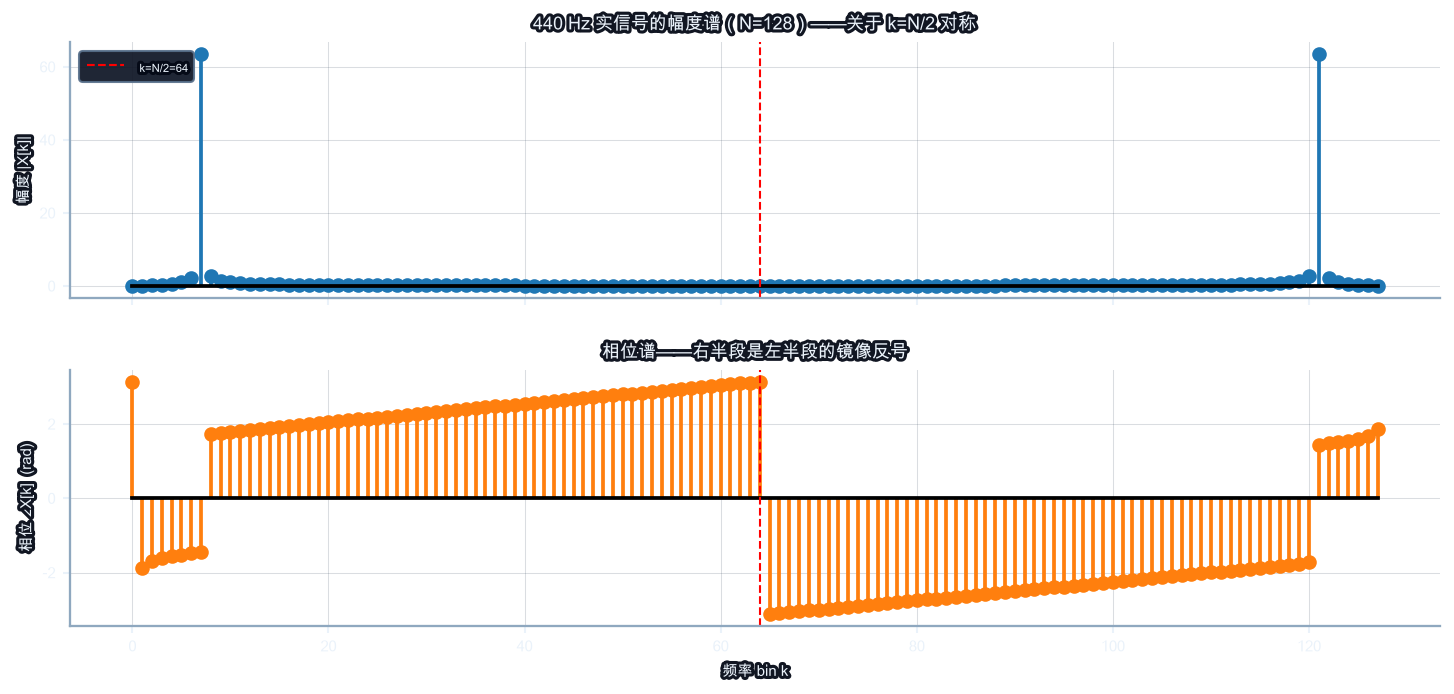

In [8]:
# 用 aurora.audio.transforms.fft 演示共轭对称
sr = 8000
duration = 0.016  # 16 ms → N=128 采样（2^7，aurora FFT 需要 2 的幂）
x = sine(440.0, sample_rate=sr, duration=duration)  # 实数信号
N = len(x)

X = fft(x)          # aurora FFT，返回复数谱
mag   = np.abs(X)
phase = np.angle(X)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
bins = np.arange(N)

axes[0].stem(bins, mag, markerfmt='C0o', linefmt='C0-', basefmt='k-')
axes[0].axvline(N//2, color='red', ls='--', lw=1, label=f'k=N/2={N//2}')
axes[0].set_ylabel('幅度 |X[k]|')
axes[0].set_title(f'440 Hz 实信号的幅度谱（N={N}）——关于 k=N/2 对称')
axes[0].legend()

axes[1].stem(bins, phase, markerfmt='C1o', linefmt='C1-', basefmt='k-')
axes[1].axvline(N//2, color='red', ls='--', lw=1)
axes[1].set_ylabel('相位 ∠X[k]  (rad)')
axes[1].set_xlabel('频率 bin k')
axes[1].set_title('相位谱——右半段是左半段的镜像反号')

plt.tight_layout()
plt.show()

# 数值验证：X[N-k] = conj(X[k])
err = np.max(np.abs(X[1:N//2] - np.conj(X[N-1:N//2:-1])))
print(f'共轭对称误差 max|X[N-k] - conj(X[k])| = {err:.2e}',
      '✅' if err < 1e-10 else '❌')

## 🏋️ 练习：手工实现 N=8 两级 Cooley-Tukey FFT

**任务**：不调用 `fft` 函数，用 NumPy 手工实现长度为 8 的迭代式 Cooley-Tukey FFT，
并与 `aurora.audio.transforms.fft` 的输出进行数值比较。

**步骤提示**：
1. 对长度 8 的输入按位逆序（bit-reversal permutation）重排：`bit_rev = [int(f'{i:03b}'[::-1], 2) for i in range(8)]`
2. 第 1 层（`half=1`）：相邻两元素做蝶形：`new_top = x[top] + W^0 * x[bot]`
3. 第 2 层（`half=2`）：跨度 2 的元素，旋转因子 `W^k = exp(-2πi·k/8)`
4. 第 3 层（`half=4`）：跨度 4 的元素，旋转因子同上
5. 对比 `aurora.audio.transforms.fft(x)` 结果，误差应低于 `1e-10`

**Aurora 连接**：`aurora.audio.transforms.fft` 就是这套算法的生产实现，完成后对比源码看看有何差异。


In [9]:
"""
复数乘法的实践例子
"""
print("复数乘法实例（蝴蝶操作中的旋转）：\n")

# 旋转因子 W^k
k = 1
N = 8
W_k = np.exp(-2j * np.pi * k / N)
print(f"旋转因子 W^{k}_{N} = exp(-2πi·{k}/{N}) = {W_k}")
print(f"  实部（余弦）= {W_k.real:.6f}")
print(f"  虚部（正弦）= {W_k.imag:.6f}")

# 待旋转的复数
X_bot = 1 + 2j
print(f"\n信号值 X[bot] = {X_bot}")

# 蝴蝶操作：乘以旋转因子
result = W_k * X_bot
print(f"\n旋转操作：W^{k} · X[bot] = {result}")
print(f"  实部 = {result.real:.6f}")
print(f"  虚部 = {result.imag:.6f}")

# 手工验证：复数乘法公式
a, b = W_k.real, W_k.imag  # W_k = a + bi
c, d = X_bot.real, X_bot.imag  # X = c + di
manual_real = a*c - b*d
manual_imag = a*d + b*c
print(f"\n手工计算验证（公式 (a+bi)(c+di) = (ac-bd) + (ad+bc)i）:")
print(f"  (a,b) = ({a:.6f}, {b:.6f})  [旋转因子]")
print(f"  (c,d) = ({c:.6f}, {d:.6f})  [信号值]")
print(f"  实部 = {a:.6f}·{c:.6f} - {b:.6f}·{d:.6f} = {manual_real:.6f} ✓")
print(f"  虚部 = {a:.6f}·{d:.6f} + {b:.6f}·{c:.6f} = {manual_imag:.6f} ✓")

print(f"\n结论：NumPy 的复数乘法自动处理了这些细节，你无需手算。")

复数乘法实例（蝴蝶操作中的旋转）：

旋转因子 W^1_8 = exp(-2πi·1/8) = (0.7071067811865476-0.7071067811865475j)
  实部（余弦）= 0.707107
  虚部（正弦）= -0.707107

信号值 X[bot] = (1+2j)

旋转操作：W^1 · X[bot] = (2.1213203435596424+0.7071067811865477j)
  实部 = 2.121320
  虚部 = 0.707107

手工计算验证（公式 (a+bi)(c+di) = (ac-bd) + (ad+bc)i）:
  (a,b) = (0.707107, -0.707107)  [旋转因子]
  (c,d) = (1.000000, 2.000000)  [信号值]
  实部 = 0.707107·1.000000 - -0.707107·2.000000 = 2.121320 ✓
  虚部 = 0.707107·2.000000 + -0.707107·1.000000 = 0.707107 ✓

结论：NumPy 的复数乘法自动处理了这些细节，你无需手算。


In [10]:
"""
演示蝶形循环的索引逻辑
"""
N = 8
stages = 3

print(f"N={N}，共 {stages} 层蝶形，每层的索引对如下：\n")

for s in range(stages):
    half = 2 ** s
    group = 2 * half
    n_groups = N // group
    
    print(f"第 {s+1} 层（stage {s}）：half={half}, group={group}, n_groups={n_groups}")
    print(f"  分组与蝶形对：")
    
    pairs = []
    for g in range(n_groups):
        for b in range(half):
            top = g * group + b
            bot = top + half
            pairs.append((top, bot))
            print(f"    组 {g}, 蝶形 {b}: (top={top}, bot={bot})")
    print()

print("观察规律：")
print("  第 1 层（half=1）：相邻两个做蝶形 (0,1), (2,3), (4,5), (6,7)")
print("  第 2 层（half=2）：隔 2 个做蝶形 (0,2), (1,3), (4,6), (5,7)")
print("  第 3 层（half=4）：隔 4 个做蝶形 (0,4), (1,5), (2,6), (3,7)")
print("\n蝶形跨度逐层翻倍，确保每个数据对都能完整处理。")

N=8，共 3 层蝶形，每层的索引对如下：

第 1 层（stage 0）：half=1, group=2, n_groups=4
  分组与蝶形对：
    组 0, 蝶形 0: (top=0, bot=1)
    组 1, 蝶形 0: (top=2, bot=3)
    组 2, 蝶形 0: (top=4, bot=5)
    组 3, 蝶形 0: (top=6, bot=7)

第 2 层（stage 1）：half=2, group=4, n_groups=2
  分组与蝶形对：
    组 0, 蝶形 0: (top=0, bot=2)
    组 0, 蝶形 1: (top=1, bot=3)
    组 1, 蝶形 0: (top=4, bot=6)
    组 1, 蝶形 1: (top=5, bot=7)

第 3 层（stage 2）：half=4, group=8, n_groups=1
  分组与蝶形对：
    组 0, 蝶形 0: (top=0, bot=4)
    组 0, 蝶形 1: (top=1, bot=5)
    组 0, 蝶形 2: (top=2, bot=6)
    组 0, 蝶形 3: (top=3, bot=7)

观察规律：
  第 1 层（half=1）：相邻两个做蝶形 (0,1), (2,3), (4,5), (6,7)
  第 2 层（half=2）：隔 2 个做蝶形 (0,2), (1,3), (4,6), (5,7)
  第 3 层（half=4）：隔 4 个做蝶形 (0,4), (1,5), (2,6), (3,7)

蝶形跨度逐层翻倍，确保每个数据对都能完整处理。


## 练习前的工具箱：复数乘法与蝶形循环结构

在动手实现前，需要理解两件事。

### 复数乘法是如何计算的？

DFT 蝶形里经常会看到 `X[bot] = X[top] - W_k * X[bot]`，其中 `W_k` 是复数，`X[bot]` 也是复数。复数乘法规则：

$$(a + bi) \times (c + di) = (ac - bd) + (ad + bc)i$$

NumPy 已经帮我们处理了这个，你只需 `W_k * X_bot`，它会自动用上面的公式。

**数值例子**：
- $W_k = e^{-i\pi/4} = \cos(\pi/4) - i\sin(\pi/4) = 0.707 - 0.707i$
- $X = 1 + 2i$
- $W_k \times X = (0.707 - 0.707i) \times (1 + 2i)$
  $= 0.707 \times 1 + 0.707 \times 2i - 0.707i \times 1 - 0.707i \times 2i$
  $= 0.707 + 1.414i - 0.707i + 1.414$（因为 $i^2 = -1$）
  $= 2.121 + 0.707i$

### 蝶形循环的索引逻辑

三层循环中的四个变量是什么意思？

```python
for s in range(3):          # s = stage（层数）0, 1, 2
    half = 2**s             # half = 1, 2, 4（蝶形跨度）
    group = 2 * half        # group = 2, 4, 8（每组大小）
    n_butterflies = N // group  # 每层有多少"组"
    
    for g in range(n_butterflies):  # g = group index（哪一组）
        for b in range(half):       # b = butterfly index in group（组内第几个蝶形）
            top = g * group + b         # 上端点
            bot = top + half            # 下端点
```

**直觉**：
- 第 1 层（half=1）：8 个元素分成 4 组（group=2），每组 2 个，相邻做蝶形
- 第 2 层（half=2）：8 个元素分成 2 组（group=4），每组 4 个，跨度 2 做蝶形
- 第 3 层（half=4）：8 个元素分成 1 组（group=8），整个数组，跨度 4 做蝶形

**为什么 `top = g * group + b, bot = top + half`？**
- `g * group + b` 是第 g 组的第 b 个元素
- `top + half` 是隔 `half` 个位置的元素（两个蝶形端点）

**代码验证**：

## 3.8 Parseval 定理：能量守恒

**问题**：时域中信号的能量（平方和）和频域中的能量应该怎样关系？它们一定相等吗？

**答案**：是的，但有个缩放因子。这就是 **Parseval 定理**：

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

其中左边是**时域能量**，右边是**频域能量**（乘以 $1/N$）。

**为什么有 $1/N$ 这个系数？** 这来自 DFT 的归一化。不同的 DFT 定义可能有不同的系数：
- 标准 DFT：$X[k] = \sum_n x[n] e^{-2\pi i kn/N}$（没有 1/N）→ Parseval 需要乘 1/N
- 有些文献用 $X[k] = \frac{1}{N} \sum_n x[n] e^{...}$（直接除 N）→ Parseval 就是等号

**物理意义**：无论你在时域看信号的强度，还是在频域看不同频率的贡献，总能量是守恒的（除了一个常数倍数）。这反映了 DFT 的**酉性**——它不"创造"或"销毁"能量。

**数值验证**（下面的代码单元）：

In [11]:
def my_fft_n8(x):
    """手工实现 N=8 的迭代式 Cooley-Tukey FFT（不调用任何 FFT 库）。

    参数：x — 长度为 8 的实数或复数 numpy 数组
    返回：长度为 8 的复数频谱数组
    """
    N = 8
    assert len(x) == N, f"需要 N=8 输入，实际 N={len(x)}"

    # TODO: Step 1 — bit-reversal 置换
    # bit_rev = [int(f'{i:03b}'[::-1], 2) for i in range(N)]
    # X = np.array([x[bit_rev[i]] for i in range(N)], dtype=complex)
    raise NotImplementedError("请实现 bit-reversal 置换和蝶形迭代")

    # TODO: Step 2 — 三层蝶形迭代
    # for s in range(3):
    #     half = 2**s
    #     group = 2 * half
    #     for g in range(N // group):
    #         for b in range(half):
    #             top = g * group + b
    #             bot = top + half
    #             W_k = np.exp(-2j * np.pi * b / group)
    #             t = X[top] + W_k * X[bot]
    #             X[bot] = X[top] - W_k * X[bot]
    #             X[top] = t

    return X


# ── 验证（带 try/except 防呆：未实现时不崩溃）──
try:
    np.random.seed(42)
    x_test = np.random.randn(8)
    result_manual = my_fft_n8(x_test)
    result_aurora = fft(x_test)

    err = np.max(np.abs(result_manual - result_aurora))
    assert err < 1e-10, f"误差过大：{err:.2e}（期望 < 1e-10）"
    print(f"✅ 验证通过：手工 FFT 与 aurora.fft 最大误差 = {err:.2e}")
    print(f"手工结果 X[0..3] = {result_manual[:4]}")
except (NotImplementedError, TypeError):
    print("⚠️  练习未实现，请填写 my_fft_n8 函数后重新运行")
except AssertionError as e:
    print(f"❌ 验证失败：{e}")


⚠️  练习未实现，请填写 my_fft_n8 函数后重新运行


## 3.6 关于 2 的幂次：为什么 aurora FFT 有这个要求？

**简短答案**：Cooley-Tukey 递推每次都把 N 折成两个 N/2。只有当 N 是 2 的幂时，才能一直折下去，最后折到 N=1（平凡情况）。

**详细推导**：
- N=8=2³ 时：8 → 4+4 → 2+2+2+2 → 1+1+1+1（可以）
- N=6=2×3 时：6 → 3+3 → 卡住！3 是奇数，没法再折

所以标准 Cooley-Tukey 算法只对 $N = 2^m$ 有效。

**如果你有 N=400 的信号怎么办？** 用 **zero-padding**（补零）：
- 找到 $2^m > 400$ 的最小 m，即 m=9（$2^9=512$）
- 把信号从 400 个点补到 512 个点（后面补 112 个零）
- 计算 FFT(512 点)，结果有 512 个 bin
- 频率分辨率变细了：原来是 sr/400，现在是 sr/512

这只会改变**分辨率**，不会改变峰值的位置（因为频率没变）。

**码**（放在参数实验之前）：

## 参数实验：双频叠加信号（纯音叠加 = 和弦雏形）

**信号参数**：`sr=8000`，`duration=0.032`（32 ms，N=256=2⁸），
叠加 `f1=440 Hz`（bin ≈ 14）和 `f2=880 Hz`（bin ≈ 28）。

> **注意**：aurora FFT 要求输入长度为 2 的幂次。为什么？Cooley-Tukey 递推每次折半，只有幂次才能一路折到底。N=400 不是 2 的幂次，须用 zero-padding 补到下一个 2 的幂次（512）。

**预期现象**：
- 幅度谱出现两个对称峰，峰位 bin 约为 `round(f * N / sr)`
- 880 Hz 的 bin 位置恰好是 440 Hz 的两倍（bin 28 = 2 × bin 14，八度关系）
- 超出 `N/2=128` 的镜像峰对称出现在高频侧（共轭对称性）

In [12]:
"""
验证频率 bin 位置公式：bin = round(f * N / sr)
"""
sr = 8000
N = 256
delta_f = sr / N  # 频率分辨率（Hz/bin）

# 几个测试频率
test_freqs = [440, 880, 1320, 4000]

print(f"采样率 sr = {sr} Hz")
print(f"采样数 N = {N}")
print(f"频率分辨率 Δf = sr/N = {delta_f:.2f} Hz/bin")
print(f"最高可识别频率 = sr/2 = {sr/2} Hz\n")

print(f"{'频率 f (Hz)':<15} {'理论 bin':<15} {'round 后':<15} {'验证：该 bin 对应的 Hz':<25}")
print("-" * 70)

for f in test_freqs:
    exact_bin = f * N / sr
    rounded_bin = round(exact_bin)
    freq_of_bin = rounded_bin * delta_f  # 反向验证：这个 bin 对应什么频率
    print(f"{f:<15} {exact_bin:<15.2f} {rounded_bin:<15} {freq_of_bin:<25.2f}")

# 图形验证：生成 440 + 880 Hz 信号，看 FFT 峰值位置
print(f"\n生成信号：440 Hz + 880 Hz（共 N={N} 采样点）")
duration = N / sr  # 秒
t = np.arange(N) / sr
x = np.sin(2 * np.pi * 440 * t) + np.sin(2 * np.pi * 880 * t)

X = np.fft.fft(x)
mag = np.abs(X)

peak_bins = np.argsort(mag)[-4:][::-1]  # 取最大的 4 个 peak
peak_freqs = peak_bins * delta_f

print(f"{'Peak index':<15} {'Frequency (Hz)':<20} {'Expected':<20}")
for peak_bin, peak_freq in zip(peak_bins, peak_freqs):
    print(f"{peak_bin:<15} {peak_freq:<20.1f} {'' if peak_freq in [440, 880, 8000-440, 8000-880] else '(镜像)'}")


采样率 sr = 8000 Hz
采样数 N = 256
频率分辨率 Δf = sr/N = 31.25 Hz/bin
最高可识别频率 = sr/2 = 4000.0 Hz

频率 f (Hz)       理论 bin          round 后         验证：该 bin 对应的 Hz          
----------------------------------------------------------------------
440             14.08           14              437.50                   
880             28.16           28              875.00                   
1320            42.24           42              1312.50                  
4000            128.00          128             4000.00                  

生成信号：440 Hz + 880 Hz（共 N=256 采样点）
Peak index      Frequency (Hz)       Expected            
14              437.5                (镜像)
242             7562.5               (镜像)
28              875.0                (镜像)
228             7125.0               (镜像)


## 3.7 频率 bin 位置公式的推导

很多学生看到 `bin = round(f * N / sr)` 都会困惑："为什么是这个公式？"。让我从采样定理推导一遍。

**背景**：
- 采样率 `sr`（单位：Hz，即每秒采样数）
- 采样数 `N`
- 总时长 $T = N / sr$（秒）

**DFT 输出**：N 个 bin，对应的频率范围是 $[0, sr)$。为什么到 `sr` 为止？因为奈奎斯特定理：最高可识别频率是 $sr/2$，超过这个的镜像了。

**bin 的频率分辨率**：$\Delta f = sr / N$（Hz/bin）

这意味着：
- bin 0 对应频率 $0 \times \Delta f = 0$ Hz
- bin 1 对应频率 $1 \times \Delta f = sr/N$ Hz
- bin k 对应频率 $k \times \Delta f = k \times sr/N$ Hz
- bin N-1 对应频率 $(N-1) \times sr/N$ Hz

**反过来找 bin**：如果信号有频率 $f$ Hz，它会落在哪个 bin？

设 bin k 对应频率 $f$，则：
$$k = \frac{f}{\Delta f} = \frac{f}{sr/N} = \frac{f \cdot N}{sr}$$

由于 k 必须是整数，实际 bin 是 $\text{round}(f \cdot N / sr)$。

**数值例子**：
- sr = 8000 Hz，N = 256，$\Delta f = 8000/256 = 31.25$ Hz/bin
- 频率 440 Hz 对应 bin = round(440 × 256 / 8000) = round(14.08) = 14
- 频率 880 Hz 对应 bin = round(880 × 256 / 8000) = round(28.16) = 28

代码验证这个公式：

440 Hz → bin 14  （理论：14.08）
880 Hz → bin 28  （理论：28.16）
两峰 bin 比值：28/14 = 2.00  （应≈2.0，八度）


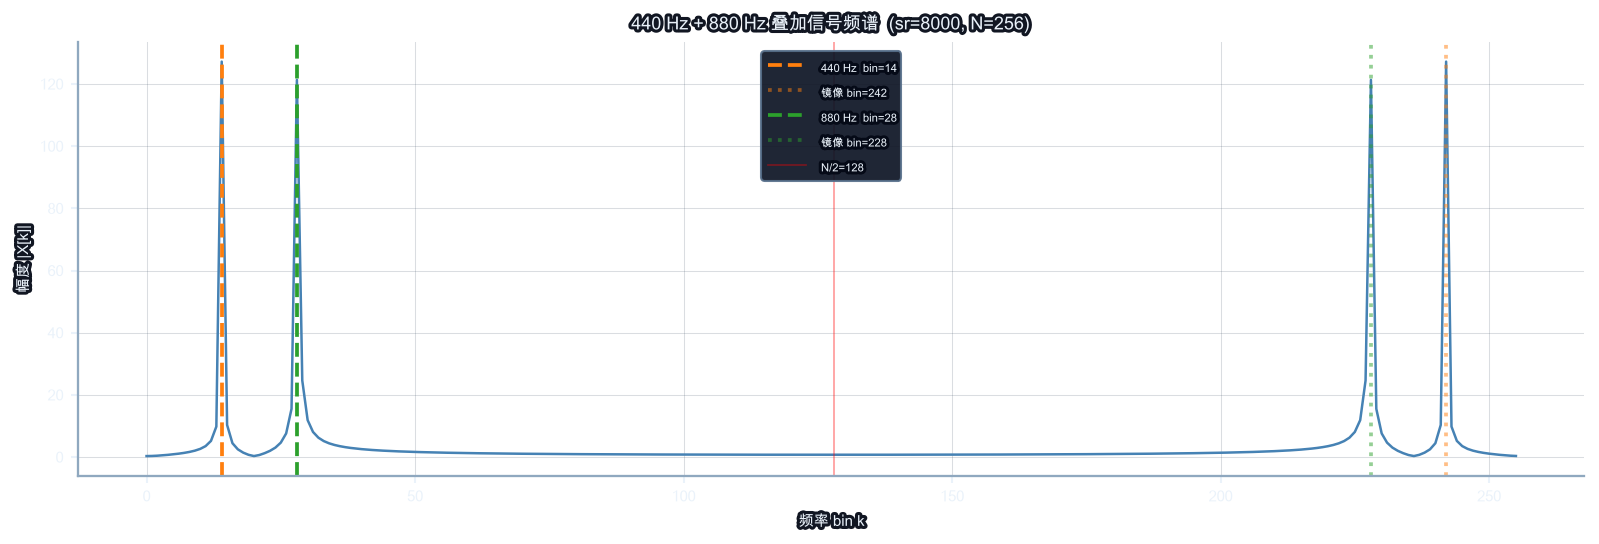

In [13]:
sr       = 8000
duration = 0.032   # 32 ms → N=256（2^8）
f1, f2   = 440.0, 880.0

x1 = sine(f1, sample_rate=sr, duration=duration)
x2 = sine(f2, sample_rate=sr, duration=duration)
x  = x1 + x2
N  = len(x)

X   = fft(x)
mag = np.abs(X)

# 理论峰值 bin
bin1 = round(f1 * N / sr)
bin2 = round(f2 * N / sr)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mag, color='steelblue', lw=1.2)
ax.axvline(bin1, color='C1', ls='--', label=f'{f1:.0f} Hz  bin={bin1}')
ax.axvline(N - bin1, color='C1', ls=':', alpha=0.5, label=f'镜像 bin={N-bin1}')
ax.axvline(bin2, color='C2', ls='--', label=f'{f2:.0f} Hz  bin={bin2}')
ax.axvline(N - bin2, color='C2', ls=':', alpha=0.5, label=f'镜像 bin={N-bin2}')
ax.axvline(N//2, color='red', ls='-', lw=0.8, alpha=0.4, label=f'N/2={N//2}')
ax.set_xlabel('频率 bin k')
ax.set_ylabel('幅度 |X[k]|')
ax.set_title(f'440 Hz + 880 Hz 叠加信号频谱  (sr={sr}, N={N})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'440 Hz → bin {bin1}  （理论：{f1*N/sr:.2f}）')
print(f'880 Hz → bin {bin2}  （理论：{f2*N/sr:.2f}）')
print(f'两峰 bin 比值：{bin2}/{bin1} = {bin2/bin1:.2f}  （应≈2.0，八度）')

## 4. 频谱形态对比：纯音 / 和弦 / 白噪声

标题承诺的三类信号在这里汇合——直观对比它们的频谱形态：

| 信号类型 | 频谱特征 | 直觉解释 |
|---|---|---|
| **纯音**（单频正弦） | 单一尖峰 + 镜像峰 | 能量集中在一个频率 |
| **和弦**（多频叠加） | 多个离散峰 | 能量分布在几个频率 |
| **白噪声** | 宽带平坦响应 | 能量均匀分布在所有频率 |


纯音   幅度谱峰值 bin = 14 (438 Hz)
和弦   幅度谱前3峰 bin = [14 21 28] 对应 Hz ≈ [437 656 875]
白噪声 幅度谱变异系数 = 0.56（值越小越平坦，白噪声理论≈1/√2）


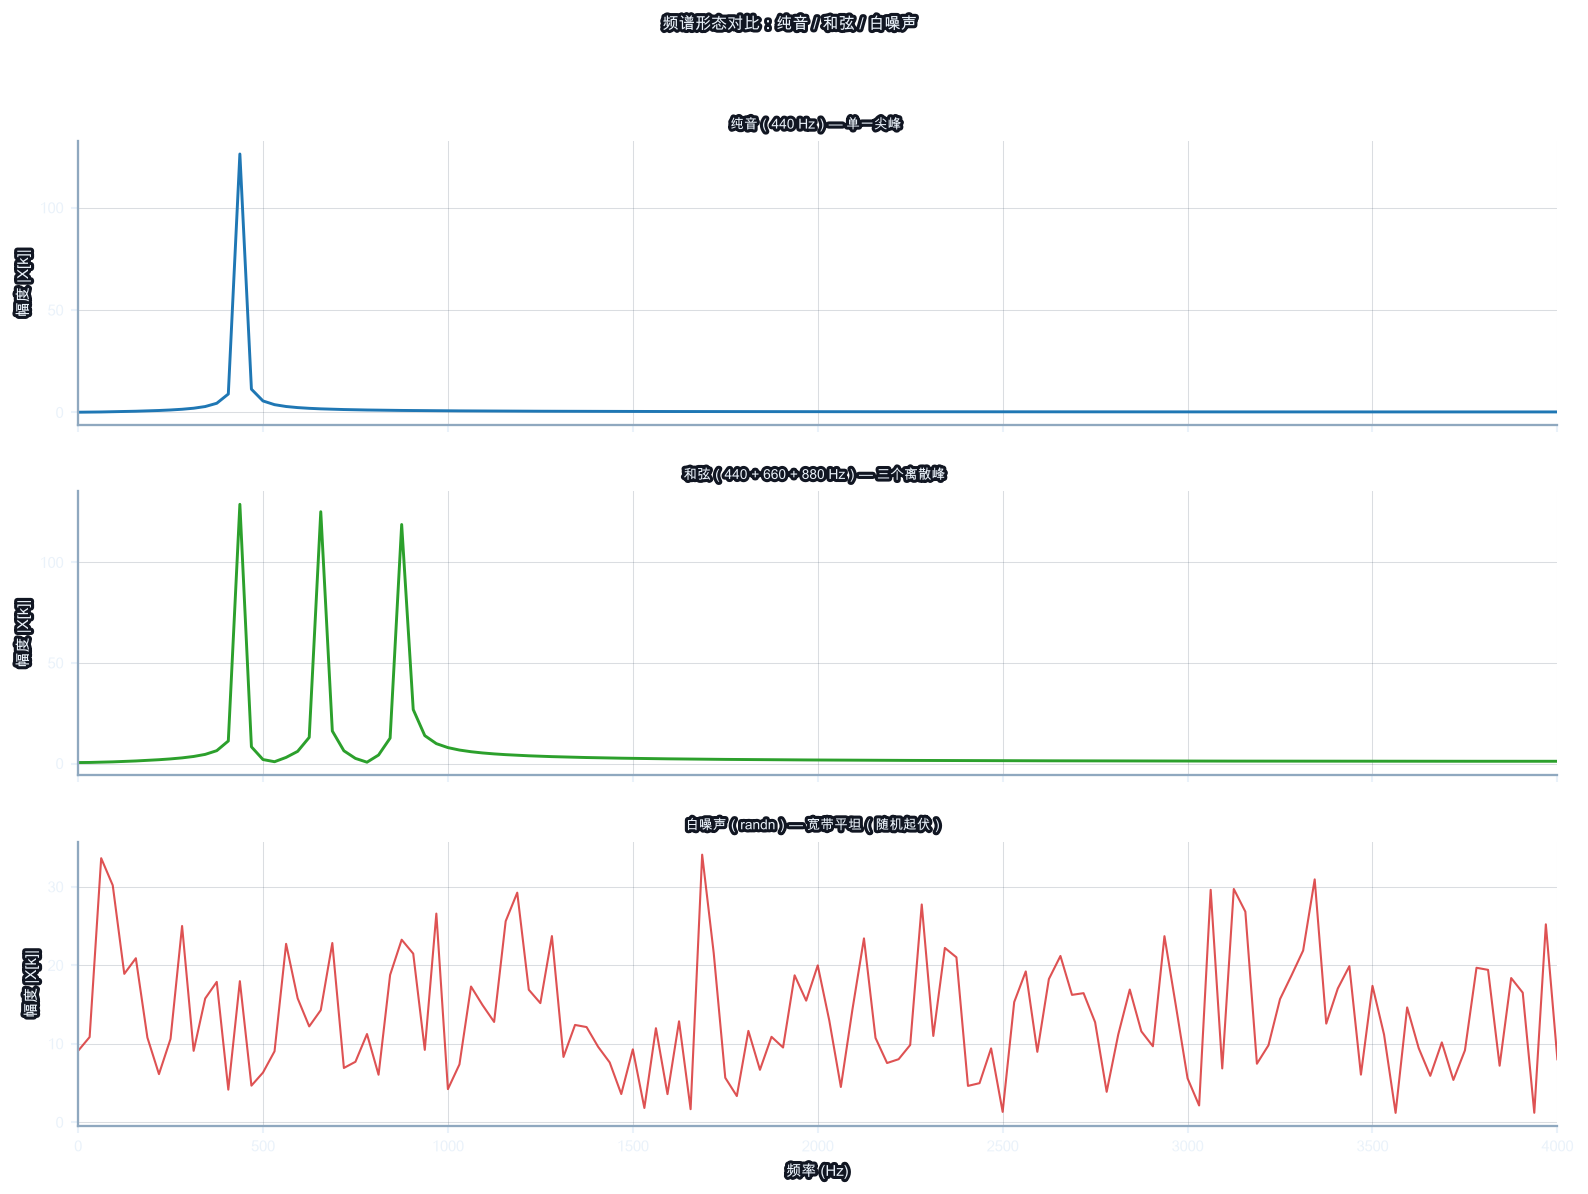

In [14]:
sr_cmp  = 8000
dur_cmp = 0.032  # 32 ms → N=256

# ── 纯音：440 Hz 单频正弦 ──
x_pure  = sine(440.0, sample_rate=sr_cmp, duration=dur_cmp)

# ── 和弦：440 + 660 + 880 Hz 三音叠加 ──
x_chord = (sine(440.0, sample_rate=sr_cmp, duration=dur_cmp) +
           sine(660.0, sample_rate=sr_cmp, duration=dur_cmp) +
           sine(880.0, sample_rate=sr_cmp, duration=dur_cmp))

# ── 白噪声：np.random.randn，理论上所有频率能量相等 ──
np.random.seed(0)
N_cmp   = len(x_pure)
x_noise = np.random.randn(N_cmp).astype(float)

# 计算各信号的幅度谱（只取前 N//2+1 个正频率 bin）
def half_spectrum(x):
    X = fft(x)
    return np.abs(X[:len(x)//2 + 1])

mag_pure  = half_spectrum(x_pure)
mag_chord = half_spectrum(x_chord)
mag_noise = half_spectrum(x_noise)

freqs = np.arange(len(mag_pure)) * sr_cmp / N_cmp

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(freqs, mag_pure, color='C0', lw=1.4)
axes[0].set_title('纯音（440 Hz）— 单一尖峰', fontsize=11)
axes[0].set_ylabel('幅度 |X[k]|')

axes[1].plot(freqs, mag_chord, color='C2', lw=1.4)
axes[1].set_title('和弦（440 + 660 + 880 Hz）— 三个离散峰', fontsize=11)
axes[1].set_ylabel('幅度 |X[k]|')

axes[2].plot(freqs, mag_noise, color='C3', lw=1.0, alpha=0.8)
axes[2].set_title('白噪声（randn）— 宽带平坦（随机起伏）', fontsize=11)
axes[2].set_ylabel('幅度 |X[k]|')
axes[2].set_xlabel('频率 (Hz)')

for ax in axes:
    ax.set_xlim(0, sr_cmp / 2)

plt.suptitle('频谱形态对比：纯音 / 和弦 / 白噪声', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 数值验证：噪声频谱均值应接近其平均幅度（平坦性粗检验）
noise_std_ratio = mag_noise.std() / mag_noise.mean()
print(f'纯音   幅度谱峰值 bin = {np.argmax(mag_pure)} ({freqs[np.argmax(mag_pure)]:.0f} Hz)')
print(f'和弦   幅度谱前3峰 bin = {np.argsort(mag_chord)[-3:][::-1]} 对应 Hz ≈ {freqs[np.argsort(mag_chord)[-3:][::-1]].astype(int)}')
print(f'白噪声 幅度谱变异系数 = {noise_std_ratio:.2f}（值越小越平坦，白噪声理论≈1/√2）')


## 本课收束

`fft`（来自 `aurora.audio.transforms`）把 N 点实信号映射为 N 个复数 bin，
通过 DFT 矩阵可视化可以看到每一行是一个复指数基，蝶形网络则揭示了
`O(N log N)` 的递归折叠结构，共轭对称保证实信号只需保留前 `N//2+1` 个 bin。
下节 `L43_stft.ipynb` 将用滑动窗口把 FFT 扩展到时频谱（STFT），
看频率随时间演变的全貌。

In [15]:
# ── 独立数学断言：验证 FFT 核心性质（无需学生实现）──────────────────────────
import numpy as np

np.random.seed(7)
x = np.random.randn(16)
N = len(x)
X = np.fft.fft(x)

# 1. DFT 矩阵酉性：F @ conj(F).T = N * I
n_arr = np.arange(N)
F = np.exp(-2j * np.pi * np.outer(n_arr, n_arr) / N)
err_unitary = np.max(np.abs(F @ F.conj().T - N * np.eye(N)))
assert err_unitary < 1e-10, f"酉性误差过大：{err_unitary:.2e}"
print(f"1 ✅  DFT 矩阵酉性：max|F·F†-N·I| = {err_unitary:.2e}")

# 2. 共轭对称：X[N-k] = conj(X[k])，k=1..N/2-1
err_sym = np.max(np.abs(X[1:N//2] - np.conj(X[N-1:N//2:-1])))
assert err_sym < 1e-10, f"共轭对称误差：{err_sym:.2e}"
print(f"2 ✅  共轭对称：max|X[N-k]-X[k]*| = {err_sym:.2e}")

# 3. Parseval 定理：Σ|x|² = (1/N)·Σ|X|²
energy_time = np.sum(np.abs(x)**2)
energy_freq = np.sum(np.abs(X)**2) / N
assert np.isclose(energy_time, energy_freq, rtol=1e-10), \
    f"Parseval 失败：时域={energy_time:.6f}，频域(1/N)={energy_freq:.6f}"
print(f"3 ✅  Parseval 定理：")
print(f"     时域能量 Σ|x[n]|² = {energy_time:.6f}")
print(f"     频域能量 (1/N)Σ|X[k]|² = {energy_freq:.6f}")
print(f"     差异 = {abs(energy_time - energy_freq):.2e}")

# 4. 线性：FFT(ax+by) = a·FFT(x) + b·FFT(y)
y = np.random.randn(N); a, b = 2.5, -1.3
assert np.allclose(np.fft.fft(a*x + b*y), a*np.fft.fft(x) + b*np.fft.fft(y), atol=1e-10)
print(f"4 ✅  线性：FFT(ax+by) = a·FFT(x)+b·FFT(y)")

# 5. DC 分量：X[0] = Σ x[n]
assert np.isclose(X[0], np.sum(x), atol=1e-10)
print(f"5 ✅  DC 分量：X[0]={X[0]:.6f}，Σx={np.sum(x):.6f}")

print("\n🎓 这些性质不仅是数学巧合，而是 DFT 作为酉变换的必然结果。")

1 ✅  DFT 矩阵酉性：max|F·F†-N·I| = 3.02e-14
2 ✅  共轭对称：max|X[N-k]-X[k]*| = 2.48e-16
3 ✅  Parseval 定理：
     时域能量 Σ|x[n]|² = 11.254872
     频域能量 (1/N)Σ|X[k]|² = 11.254872
     差异 = 3.55e-15
4 ✅  线性：FFT(ax+by) = a·FFT(x)+b·FFT(y)
5 ✅  DC 分量：X[0]=-1.508416+0.000000j，Σx=-1.508416

🎓 这些性质不仅是数学巧合，而是 DFT 作为酉变换的必然结果。


## 附录 · 从「整段 FFT」到「STFT」：多出来的一个维度

L41 回答的是：**这一整段加窗信号里有哪些频率？** 输出是一维频谱。

STFT 回答的是：**每个时间段里有哪些频率？** 输出是二维矩阵：

```text
STFT shape ≈ (n_frames, n_bins)   # 时间 × 频率
```

你已经有的零件：

| 零件 | 来源课 | 作用 |
|---|---|---|
| 窗函数 `w` | L36 | 压低每帧边缘 |
| FFT | L39 | 把每帧变成频谱 |
| 分帧 | L43（下一课） | 滑动切出 `(n_frames, win_len)` |

三个新参数：

- `win_len`：帧长，越大频率越细（Δf = sr / win_len）
- `hop`：帧步进，越小时间越密（Δt = hop / sr）
- `window`：通常 Hann（L36）

帧数公式（无 center 补零时）：

```text
n_frames = 1 + (len(x) - win_len) // hop
```

ASCII 直觉：

```text
x:  |----|----|----|----|----|----|
       [win]
          [win]   ← hop 步进
             [win]
```

L44 不是新算法，而是把 **分帧 → 乘窗 → FFT** 串成 `my_stft`。


---

→ **下一课**　[L43 · STFT 原理](L43_stft.ipynb)

> 下节课将学习 **STFT 原理**：短时傅里叶变换：给信号加时间戳，时频分辨率 tradeoff。